<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/02_adk_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

#### Install Dependencies

In [1]:
!pip install google-adk google-cloud-aiplatform google-api-python-client google-auth-httplib2 google-auth-oauthlib langsmith -q
!pip show google-adk

Name: google-adk
Version: 1.29.0
Summary: Agent Development Kit
Home-page: https://google.github.io/adk-docs/
Author: 
Author-email: Google LLC <googleapis-packages@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiosqlite, anyio, authlib, click, fastapi, google-api-python-client, google-auth, google-cloud-aiplatform, google-cloud-bigquery, google-cloud-bigquery-storage, google-cloud-bigtable, google-cloud-dataplex, google-cloud-discoveryengine, google-cloud-pubsub, google-cloud-secret-manager, google-cloud-spanner, google-cloud-speech, google-cloud-storage, google-genai, graphviz, httpx, jsonschema, mcp, opentelemetry-api, opentelemetry-exporter-gcp-logging, opentelemetry-exporter-gcp-monitoring, opentelemetry-exporter-gcp-trace, opentelemetry-exporter-otlp-proto-http, opentelemetry-resourcedetector-gcp, opentelemetry-sdk, pyarrow, pydantic, python-dateutil, python-dotenv, PyYAML, requests, sqlalchemy, sqlalchemy-spanner, starlette, tenacity, typing-e

#### Load Secrets

In [2]:
from google.colab import userdata

PROJECT_ID = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

print("Project:", PROJECT_ID[:15])
print("Location:", LOCATION)
print("Datastore:", DATASTORE_ID[:15])

Project: edu-teacher-ass
Location: global
Datastore: curriculum-conn


In [3]:
# LangSmith Tracing
import os
from google.colab import userdata
from langsmith.integrations.google_adk import configure_google_adk

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "langgraph-adk-edu-comparison"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

configure_google_adk()

print("LangSmith tracing enabled (native ADK integration)")
print("Project: mfu-teacher-assistant-comparison")

/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


LangSmith tracing enabled (native ADK integration)
Project: mfu-teacher-assistant-comparison


#### Google Authentication

In [4]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, project = google.auth.default()
print("Authenticated")
print("Project:", project)

Authenticated
Project: 


#### Set Project and Verify

In [5]:
import os
from google.colab import userdata

PROJECT_ID = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "1"

import vertexai
vertexai.init(project=PROJECT_ID, location="us-central1")

from google.cloud import aiplatform
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project:", PROJECT_ID[:15])
print("Search Location:", LOCATION)
print("Datastore:", DATASTORE_ID[:15])
print("Vertex AI backend enabled for ADK")

Project: edu-teacher-ass
Search Location: global
Datastore: curriculum-conn
Vertex AI backend enabled for ADK


#### ADK Import & Version

In [6]:
import google.adk
print("ADK version:", google.adk.__version__)

from google.adk.agents import LlmAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools.agent_tool import AgentTool
from google.genai import types

print("All ADK imports successful")

ADK version: 1.29.0
All ADK imports successful


# Sub Agents

In [7]:
from google.genai import types
from google.adk.models.google_llm import Gemini

resilient_http_options = types.HttpOptions(
    retry_options=types.HttpRetryOptions(
        attempts=5, initial_delay=5.0,
        http_status_codes=[408, 429, 500, 502, 503, 504]
    )
)

resilient_pro = Gemini(
    model="gemini-2.5-pro",
    http_options=resilient_http_options,
    generate_content_config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_budget=0)
    ),
)
resilient_flash = Gemini(
    model="gemini-2.5-flash",
    http_options=resilient_http_options,
    generate_content_config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_budget=0)
    ),
)
print("ADK models initialised — thinking DISABLED for fair token comparison.")

ADK models initialised — thinking DISABLED for fair token comparison.


#### Tool: Vertex AI Search

In [8]:
from google.cloud import discoveryengine_v1 as discoveryengine
from langsmith import traceable

In [9]:
@traceable(
    name="retrieve_course_materials",
    run_type="retriever",
    metadata={"framework": "Google ADK", "source": "vertex-ai-search"}
)
def retrieve_course_materials(
    query: str,
    page_size: int = 5,
) -> str:
    """
    Search the curriculum datastore for relevant course materials
    from Mae Fah Luang University.

    Use a descriptive query based on the instructor's actual request topic.

    For page_size:
    - Use 6-8 for lesson plans (need rich, detailed content)
    - Use 6-8 for quizzes (need diverse content for 10 varied questions)
    - Use 2-3 for emails (only need light topic context)

    Args:
        query:     Natural language search query based on the topic requested.
        page_size: Number of results to retrieve. Agent should choose based on task.

    Returns:
        Relevant course material snippets, or "No relevant materials found."
    """
    client = discoveryengine.SearchServiceClient()

    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )

    request = discoveryengine.SearchRequest(
        serving_config=serving_config,
        query=query,
        page_size=page_size,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=min(page_size, 5),
                include_citations=True,
            ),
        ),
    )

    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for snippet in doc.derived_struct_data.get("snippets", []):
                text = snippet.get("snippet", "").strip()
                if text:
                    snippets.append(text)

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."

#### Lesson Planner Agent

In [10]:
from google.adk.agents import LlmAgent

lesson_planner_agent = LlmAgent(
    name="lesson_planner_agent",
    model=resilient_flash,
    description=(
        "Creates detailed lesson plans aligned with course materials. "
        "Use this agent when the instructor requests a lesson plan, course outline, or lecture notes."
    ),
    instruction="""You are an expert curriculum designer at Mae Fah Luang University.

Your workflow:
1. Use `retrieve_course_materials` to fetch relevant content for the topic.
2. Generate a comprehensive lesson plan that includes:
   - Learning Objectives
   - Duration and timing breakdown (90-minute class)
   - Teaching methods and student activities
   - Assessment strategy
   - Required materials
3. Return the complete lesson plan as your final response.

Always ground your lesson plan in the retrieved course materials.""",
    tools=[retrieve_course_materials]
)

print("Lesson Planner Agent created")
print("   Model:", lesson_planner_agent.model)
print("   Tools:", [t.__name__ for t in lesson_planner_agent.tools])

Lesson Planner Agent created
   Model: model='gemini-2.5-flash' base_url=None speech_config=None use_interactions_api=False retry_options=None
   Tools: ['retrieve_course_materials']


#### Quiz Generator Agent

In [11]:
quiz_generator_agent = LlmAgent(
    name="quiz_generator_agent",
    model=resilient_flash,
    description=(
        "Generates a multiple choice quiz from course materials. "
        "Use this agent when the instructor requests a quiz, test, or assessment."
    ),
    instruction="""You are a quiz content specialist and publisher at Mae Fah Luang University.

Your workflow:
1. Use `retrieve_course_materials` to fetch relevant content (page_size=8 for diverse questions).
2. Generate exactly 10 multiple-choice questions grounded in the retrieved materials.
3. Present the quiz in clean, readable format:
   - Number each question
   - List all 4 options with A/B/C/D labels
   - Mark the correct answer with ✅
   - Include the explanation

Present all 10 questions clearly in your final response.""",
    tools=[retrieve_course_materials],
)

print("Quiz Generator Agent created (single LlmAgent, no SequentialAgent)")
print("   Model:", quiz_generator_agent.model)
print("   Tools:", [t.__name__ for t in quiz_generator_agent.tools])

Quiz Generator Agent created (single LlmAgent, no SequentialAgent)
   Model: model='gemini-2.5-flash' base_url=None speech_config=None use_interactions_api=False retry_options=None
   Tools: ['retrieve_course_materials']


#### Email Agent

In [13]:
from google.adk.tools import FunctionTool

def send_email_to_students(subject: str, body: str) -> str:
    """
    Sends an email to all students in the course.

    Args:
        subject: The email subject line
        body: The full email body text

    Returns:
        Confirmation message that email was sent
    """
    print(f"\n📧 EMAIL SENT")
    print(f"   Subject: {subject}")
    print(f"   Body preview: {body[:100]}...")
    return f"Email successfully sent to all students. Subject: '{subject}'"

email_send_tool = FunctionTool(func=send_email_to_students)
print("Email send tool defined")
print("Tool name:", email_send_tool.name)

Email send tool defined
Tool name: send_email_to_students


In [26]:
from google.adk.tools.base_tool import BaseTool
from google.adk.agents.callback_context import CallbackContext
from typing import Optional

def instructor_approval_callback(
    tool: BaseTool,
    args: dict,                    # ← renamed from tool_input to args
    tool_context: CallbackContext,
) -> Optional[dict]:
    """
    Pauses execution and asks the instructor to approve before sending the email.
    """
    print("\n" + "="*60)
    print("🔔 HITL APPROVAL REQUIRED")
    print("="*60)
    print(f"Tool    : {tool.name}")
    print(f"Subject : {args.get('subject', 'N/A')}")
    print(f"Body    :\n{args.get('body', 'N/A')}")
    print("="*60)

    approval = input("Approve sending? (yes/no): ").strip().lower()

    if approval == "yes":
        print("✅ Approved — sending email.")
        return None                # proceed normally
    else:
        print("❌ Rejected — email cancelled.")
        return {"result": "Email rejected by instructor. Not sent."}

print("HITL instructor approval callback defined (ADK 1.27.1 signature)")

HITL instructor approval callback defined (ADK 1.27.1 signature)


In [27]:
email_agent = LlmAgent(
    name="email_agent",
    model=resilient_flash,
    description="""
    Drafts a student email, requests instructor approval via HITL,
    then confirms sending. Use this when the instructor wants to send
    an email or announcement to students.
    """,
    instruction="""You are a professional email drafting and dispatch agent for Mae Fah Luang University.

Your workflow:
1. Draft a professional email to students based on the instructor's request.
   - Format: SUBJECT: <subject line>\n\nBODY:\n<email body>
   - Use formal university tone.
2. Call `send_email_to_students` with the subject and body.
3. Report the final result (sent or rejected) to the instructor.""",
    tools=[email_send_tool],
    before_tool_callback=instructor_approval_callback,
)

print("Email Agent created (single LlmAgent, no SequentialAgent)")
print("  Tools:", [t.name for t in email_agent.tools])

Email Agent created (single LlmAgent, no SequentialAgent)
  Tools: ['send_email_to_students']


# ROOT Orchestrator

In [28]:
from google.adk.tools.agent_tool import AgentTool

root_orchestrator = LlmAgent(
    name="teacher_assistant_orchestrator",
    model=resilient_pro,
    description="Root AI Teaching Assistant orchestrator for Mae Fah Luang University instructors.",
    instruction="""You are the AI Teaching Assistant for Mae Fah Luang University instructors.

You help lecturers with three types of tasks:
1. **Lesson Plans** — creating structured lesson plans from course materials
2. **Quizzes** — generating multiple choice assessments
3. **Emails** — drafting and sending communications to students

For each request:
1. Identify the task type.
2. Delegate to the appropriate specialist agent.
3. Report the full result back to the instructor.

Always confirm which action was taken and provide the complete output.""",
    tools=[
        AgentTool(agent=lesson_planner_agent),
        AgentTool(agent=quiz_generator_agent),
        AgentTool(agent=email_agent)
    ]
)

print("Root Orchestrator created")
print("   Model:", root_orchestrator.model)
print("   Tools:", [t.name for t in root_orchestrator.tools])

Root Orchestrator created
   Model: model='gemini-2.5-pro' base_url=None speech_config=None use_interactions_api=False retry_options=None
   Tools: ['lesson_planner_agent', 'quiz_generator_agent', 'email_agent']


# Runner SetUP

In [29]:
import asyncio, uuid, time
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree

APP_NAME = "teacher-assistant-adk"
USER_ID  = "mfu-instructor-01"

session_service = InMemorySessionService()
runner = Runner(
    agent=root_orchestrator,
    app_name=APP_NAME,
    session_service=session_service,
)

@traceable(name="run_request", run_type="chain",
           metadata={"framework": "Google ADK", "app": "teacher-assistant-adk"})
async def run_request(user_input: str, scenario: str = "unknown"):
    session_id = str(uuid.uuid4())
    await session_service.create_session(
        app_name=APP_NAME, user_id=USER_ID, session_id=session_id,
    )
    message = types.Content(role="user", parts=[types.Part(text=user_input)])

    run_tree = get_current_run_tree()
    ls_run_id = str(run_tree.id) if run_tree else None

    start = time.time()
    final_response = ""

    async for event in runner.run_async(
        user_id=USER_ID, session_id=session_id, new_message=message,
    ):
        if event.is_final_response() and event.content:
            final_response = event.content.parts[0].text.strip()

    fallback_latency = round(time.time() - start, 2)
    return final_response, fallback_latency, ls_run_id

print("run_request ready (token counting delegated to LangSmith).")
print("App:", APP_NAME)
print("User:", USER_ID)

run_request ready (token counting delegated to LangSmith).
App: teacher-assistant-adk
User: mfu-instructor-01


#### Fetch from Langsmith

In [18]:
from langsmith import Client
import os

ls_client = Client(api_key=os.environ["LANGCHAIN_API_KEY"])
LS_PROJECT = os.environ["LANGCHAIN_PROJECT"]

def get_langsmith_latency(run_name: str, scenario_tag: str = None, limit: int = 1) -> float:
    """
    Fetch the latency of the most recent run matching run_name from LangSmith.
    Returns latency in seconds, or None if not found.
    """
    runs = list(ls_client.list_runs(
        project_name=LS_PROJECT,
        filter=f'eq(name, "{run_name}")',
        limit=limit,
    ))
    if not runs:
        print(f"[LangSmith] No runs found for: {run_name}")
        return None

    run = runs[0]  # most recent
    if run.end_time and run.start_time:
        latency = (run.end_time - run.start_time).total_seconds()
        return round(latency, 2)
    return None

print("LangSmith latency fetcher ready.")

LangSmith latency fetcher ready.


In [19]:
import time as _time

async def fetch_ls_latency(ls_run_id: str, max_wait: int = 30, poll_interval: int = 4) -> tuple[float | None, str]:
    """
    Poll LangSmith until the run has end_time, or give up after max_wait seconds.
    Returns (clean_latency_or_None, latency_source).
    """
    if not ls_run_id:
        return None, "fallback"

    deadline = _time.time() + max_wait
    while _time.time() < deadline:
        try:
            run = ls_client.read_run(ls_run_id)
            if run.end_time and run.start_time:
                latency = round((run.end_time - run.start_time).total_seconds(), 2)
                return latency, "langsmith"
        except Exception:
            pass  # run not indexed yet
        await asyncio.sleep(poll_interval)

    print(f"  [LangSmith] Run {ls_run_id} not ready after {max_wait}s — using fallback")
    return None, "fallback"

In [20]:
async def fetch_ls_tokens(ls_run_id: str, max_wait: int = 30, poll_interval: int = 4) -> dict:
    """
    Poll LangSmith until the root run has token usage, or give up.
    Returns dict with input_tokens, output_tokens, total_tokens (thought-free).
    """
    if not ls_run_id:
        return {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0}

    deadline = _time.time() + max_wait
    while _time.time() < deadline:
        try:
            run = ls_client.read_run(ls_run_id)
            if run.prompt_tokens is not None:
                return {
                    "input_tokens":  run.prompt_tokens,
                    "output_tokens": run.completion_tokens,
                    "total_tokens":  run.total_tokens,
                }
        except Exception:
            pass
        await asyncio.sleep(poll_interval)

    print(f"  [LangSmith] Tokens for {ls_run_id} not ready after {max_wait}s — using 0")
    return {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0}

print("LangSmith token fetcher ready.")

LangSmith token fetcher ready.


# Metrics Logger

In [21]:
import csv, os
from datetime import datetime, timezone

METRICS_FILE = "adk_metrics.csv"
FIELDNAMES = [
    "timestamp", "scenario", "framework", "routing_correct",
    "latency_sec", "latency_source",
    "input_tokens", "output_tokens", "total_tokens",
    "response_length", "error"
]

def log_metric(scenario, routing_correct, latency, response="",
               input_tokens=0, output_tokens=0, total_tokens=0,
               latency_source="fallback", error=""):
    write_header = not os.path.exists(METRICS_FILE)
    with open(METRICS_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        writer.writerow({
            "timestamp":       datetime.now(timezone.utc).isoformat(),
            "scenario":        scenario,
            "framework":       "Google ADK",
            "routing_correct": routing_correct,
            "latency_sec":     latency,
            "latency_source":  latency_source,
            "input_tokens":    input_tokens,
            "output_tokens":   output_tokens,
            "total_tokens":    total_tokens,
            "response_length": len(response),
            "error":           error,
        })
    print(f"Logged: {scenario} | {latency}s ({latency_source}) | in={input_tokens} out={output_tokens} total={total_tokens}")

print("Metrics logger ready (with thought token tracking).")

Metrics logger ready (with thought token tracking).


# Scenario 1: Lesson Plan Generation

In [22]:
import asyncio

In [23]:
SCENARIO_1_PROMPT = "Create a 90-minute lesson plan for week 1 on Software Testing for second-year Software Engineering students. Align it with the course materials."

print("Running Scenario 1 - Lesson Plan Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, ls_run_id = await run_request(
            user_input=SCENARIO_1_PROMPT,
            scenario="Scenario 1 - Lesson Plan",
        )

        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        tokens = await fetch_ls_tokens(ls_run_id)

        routing_correct = "lesson plan" in response.lower() or \
                          "learning objectives" in response.lower()

        log_metric(
            scenario        = "Scenario 1 - Lesson Plan",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = tokens["input_tokens"],
            output_tokens   = tokens["output_tokens"],
            total_tokens    = tokens["total_tokens"],
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Tokens:  in={tokens['input_tokens']} out={tokens['output_tokens']} total={tokens['total_tokens']}")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 1 - Lesson Plan",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 20s before next run...")
        try:
            await asyncio.sleep(20)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 1 complete.")

Running Scenario 1 - Lesson Plan Generation (5 runs)
------------------------------------------------------------

Run 1/5...


Logged: Scenario 1 - Lesson Plan | 26.75s (langsmith) | in=2864 out=2413 total=5791
  Latency: 26.75s (langsmith)  |  Fallback: 26.71s
  Routing: True
  Length:  5308 chars
  Tokens:  in=2864 out=2413 total=5791
  Preview: I have created a 90-minute lesson plan for Week 1 on Software Testing for second-year Software Engineering students, as ...
  Waiting 20s before next run...

Run 2/5...
Logged: Scenario 1 - Lesson Plan | 24.27s (langsmith) | in=2622 out=1942 total=5223
  Latency: 24.27s (langsmith)  |  Fallback: 24.27s
  Routing: True
  Length:  4212 chars
  Tokens:  in=2622 out=1942 total=5223
  Preview: I have created a 90-minute lesson plan for Week 1 on Software Testing, as you requested. Here is the complete plan:

---...
  Waiting 20s before next run...

Run 3/5...
Logged: Scenario 1 - Lesson Plan | 23.65s (langsmith) | in=2762 out=2128 total=5298
  Latency: 23.65s (langsmith)  |  Fallback: 23.65s
  Routing: True
  Length:  4547 chars
  Tokens:  in=2762 out=2128 total=5298
  Pr

# Scenario 2: Quiz Generator

In [24]:
SCENARIO_2_PROMPT = "Generate 10 multiple-choice questions on Software Testing from the course materials."

print("Running Scenario 2 - Quiz Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, ls_run_id = await run_request(
            user_input=SCENARIO_2_PROMPT,
            scenario="Scenario 2 - Quiz Generation",
        )

        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        tokens = await fetch_ls_tokens(ls_run_id)

        routing_correct = "question" in response.lower() or \
                          "quiz" in response.lower() or \
                          "multiple choice" in response.lower()

        log_metric(
            scenario        = "Scenario 2 - Quiz Generation",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = tokens["input_tokens"],
            output_tokens   = tokens["output_tokens"],
            total_tokens    = tokens["total_tokens"],
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Tokens:  in={tokens['input_tokens']} out={tokens['output_tokens']} total={tokens['total_tokens']}")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 2 - Quiz Generation",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 20s before next run...")
        try:
            await asyncio.sleep(20)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 2 complete.")

Running Scenario 2 - Quiz Generation (5 runs)
------------------------------------------------------------

Run 1/5...
Logged: Scenario 2 - Quiz Generation | 31.63s (langsmith) | in=2533 out=1871 total=6878
  Latency: 31.63s (langsmith)  |  Fallback: 31.62s
  Routing: True
  Length:  4195 chars
  Tokens:  in=2533 out=1871 total=6878
  Preview: I have generated 10 multiple-choice questions on Software Testing for you. Here is the complete quiz:

Here are 10 multi...
  Waiting 20s before next run...

Run 2/5...
Logged: Scenario 2 - Quiz Generation | 38.63s (langsmith) | in=2882 out=2415 total=6032
  Latency: 38.63s (langsmith)  |  Fallback: 38.63s
  Routing: True
  Length:  5442 chars
  Tokens:  in=2882 out=2415 total=6032
  Preview: I have generated a 10-question multiple-choice quiz on Software Testing from the course materials, as you requested. Her...
  Waiting 20s before next run...

Run 3/5...
Logged: Scenario 2 - Quiz Generation | 23.63s (langsmith) | in=2419 out=1663 total=5711
 

# Scenario 3: Email With HITL

In [54]:
SCENARIO_3_PROMPT = "Draft and send an email to all students reminding them that the Software Testing quiz covering Unit Testing and Black Box Testing is next Monday at 9am. Include what topics to study and how to prepare."

print("Running Scenario 3 - Email with HITL (5 runs)")
print("-" * 60)
print("Note: Each run will pause for your approval input (yes/no)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, ls_run_id = await run_request(
            user_input=SCENARIO_3_PROMPT,
            scenario="Scenario 3 - Email HITL",
        )

        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        tokens = await fetch_ls_tokens(ls_run_id)

        routing_correct = "email" in response.lower() or \
                          "subject" in response.lower() or \
                          "dear" in response.lower()

        log_metric(
            scenario        = "Scenario 3 - Email HITL",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = tokens["input_tokens"],
            output_tokens   = tokens["output_tokens"],
            total_tokens    = tokens["total_tokens"],
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Tokens:  in={tokens['input_tokens']} out={tokens['output_tokens']} total={tokens['total_tokens']}")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 3 - Email HITL",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 20s before next run...")
        try:
            await asyncio.sleep(20)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 3 complete.")

Running Scenario 3 - Email with HITL (5 runs)
------------------------------------------------------------
Note: Each run will pause for your approval input (yes/no)
------------------------------------------------------------

Run 1/5...

🔔 HITL APPROVAL REQUIRED
Tool    : send_email_to_students
Subject : Reminder: Software Testing Quiz Next Monday
Body    :
Dear Students,

This is a reminder regarding the upcoming Software Testing quiz, scheduled for next Monday at 9:00 AM.

The quiz will cover Unit Testing and Black Box Testing. To prepare effectively, please review all relevant lecture materials, course readings, and assignments related to these topics. We encourage you to go over practical examples and exercises to solidify your understanding.

Should you have any questions, please do not hesitate to reach out to your instructor during office hours or via email.

Best regards,

Mae Fah Luang University
Approve sending? (yes/no): yes
✅ Approved — sending email.

📧 EMAIL SENT
   Sub

# Metrics Summary

In [55]:
import pandas as pd

df = pd.read_csv("adk_metrics.csv")

# Flag rows where LangSmith token fetch timed out
df["token_fetch_failed"] = df["total_tokens"] == 0

summary = df[df["token_fetch_failed"] == False].groupby("scenario").agg(
    runs            = ("latency_sec", "count"),
    avg_latency     = ("latency_sec", "mean"),
    routing_acc     = ("routing_correct", "mean"),
    avg_input_tok   = ("input_tokens", "mean"),
    avg_output_tok  = ("output_tokens", "mean"),
    avg_total_tok   = ("total_tokens", "mean"),
    token_source    = ("latency_source", lambda x: "langsmith"),
).round(2)

failed_rows = df["token_fetch_failed"].sum()
if failed_rows > 0:
    print(f"⚠️  WARNING: {failed_rows} rows had token_fetch_failed=True and were excluded from token averages")

print(summary.to_string())

                              runs  avg_latency  routing_acc  avg_input_tok  avg_output_tok  avg_total_tok token_source
scenario                                                                                                               
Scenario 1 - Lesson Plan         5        29.75          1.0         3896.0          2130.2         6945.4    langsmith
Scenario 2 - Quiz Generation     5        27.33          1.0         2640.6          2052.8         5926.0    langsmith
Scenario 3 - Email HITL          5        14.72          1.0         1943.4           397.8         2816.2    langsmith


# Final Analysis & Report

In [56]:
summary = df.groupby("scenario").agg(
    runs             = ("latency_sec",     "count"),
    avg_latency      = ("latency_sec",     "mean"),
    min_latency      = ("latency_sec",     "min"),
    max_latency      = ("latency_sec",     "max"),
    routing_accuracy = ("routing_correct", "mean"),
    avg_input_tok    = ("input_tokens",    "mean"),
    avg_output_tok   = ("output_tokens",   "mean"),
    avg_total_tok    = ("total_tokens",    "mean"),
    langsmith_pct    = ("latency_source",  lambda x: round((x == "langsmith").mean() * 100, 1)),
).round(2)

print("=" * 60)
print("       Google ADK — Final Experiment Report")
print("=" * 60)
print(summary.to_string())

print("\n--- Per-Run Detail ---")
print(df[["scenario", "latency_sec", "latency_source",
          "input_tokens", "output_tokens",
          "total_tokens",
          "routing_correct", "error"]].to_string())

from google.colab import files
files.download(METRICS_FILE)
print(f"\nDownloaded: {METRICS_FILE}")

       Google ADK — Final Experiment Report
                              runs  avg_latency  min_latency  max_latency  routing_accuracy  avg_input_tok  avg_output_tok  avg_total_tok  langsmith_pct
scenario                                                                                                                                                
Scenario 1 - Lesson Plan         5        29.75        23.65        44.68               1.0         3896.0          2130.2         6945.4          100.0
Scenario 2 - Quiz Generation     5        27.33        20.79        38.63               1.0         2640.6          2052.8         5926.0          100.0
Scenario 3 - Email HITL          5        14.72        10.91        21.19               1.0         1943.4           397.8         2816.2          100.0

--- Per-Run Detail ---
                        scenario  latency_sec latency_source  input_tokens  output_tokens  total_tokens  routing_correct  error
0       Scenario 1 - Lesson Plan       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded: adk_metrics.csv


# Latency Visualization

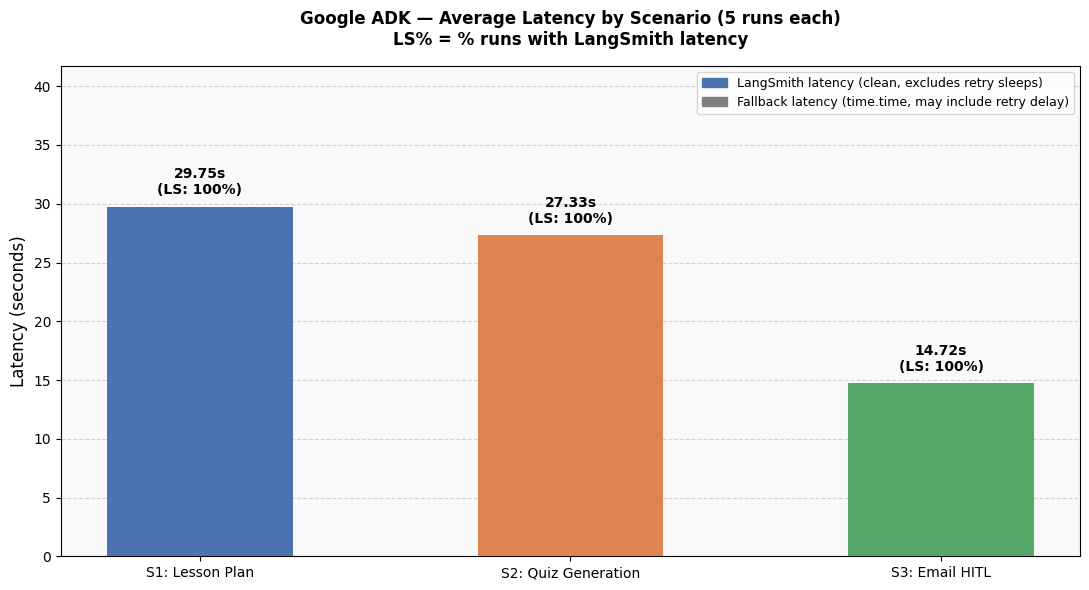

Chart saved: adk_latency_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Build per-scenario stats
scenarios_raw = ["Scenario 1 - Lesson Plan", "Scenario 2 - Quiz Generation", "Scenario 3 - Email HITL"]
labels        = ["S1: Lesson Plan", "S2: Quiz Generation", "S3: Email HITL"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]

avg_latencies = []
ls_pcts       = []

for s in scenarios_raw:
    subset = df[df["scenario"] == s]["latency_sec"]
    avg_latencies.append(subset.mean())
    pct = (df[df["scenario"] == s]["latency_source"] == "langsmith").mean() * 100
    ls_pcts.append(pct)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(labels, avg_latencies, color=colors, width=0.5, zorder=3)

# Value labels + latency source % on top of each bar
for bar, val, pct in zip(bars, avg_latencies, ls_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.2f}s\n(LS: {pct:.0f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title(
    "Google ADK — Average Latency by Scenario (5 runs each)\n"
    "LS% = % runs with LangSmith latency",
    fontsize=12, fontweight="bold", pad=15
)
ax.set_ylabel("Latency (seconds)", fontsize=12)
ax.set_ylim(0, max(avg_latencies) + 12)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.set_facecolor("#f9f9f9")

ls_patch = mpatches.Patch(color="#4C72B0", label="LangSmith latency (clean, excludes retry sleeps)")
fb_patch = mpatches.Patch(color="gray",    label="Fallback latency (time.time, may include retry delay)")
ax.legend(handles=[ls_patch, fb_patch], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("adk_latency_chart.png", dpi=150)
plt.show()
print("Chart saved: adk_latency_chart.png")

from google.colab import files
files.download("adk_latency_chart.png")